# YOLO11s Stock Baseline on Caltech Camera Traps (CCT)

This notebook builds a simple **baseline model** so we can compare it fairly with our modified YOLO11s model.

## What stays the same as the modified run
To make the comparison fair, this notebook keeps the following parts the same:
- same dataset
- same COCO JSON to YOLO conversion
- same splits: train, cis_val, trans_val, cis_test, trans_test
- same KEEP_EMPTY_TRAIN_FRAC = 0.25
- same FILTER_TINY_BOXES_PX = 4
- same use of trans_val as the main validation split
- same optimizer, learning rate schedule, warmup, and patience
- same Albumentations augmentation setup
- same weighted classification loss
- same final evaluation on cis_test and trans_test

## What changes
The only thing that changes is the model architecture:
- **baseline in this notebook:** normal stock YOLO("yolo11s.pt")
- **modified model:** YOLO11s with CBAM + InstanceNorm


## 1. Check required packages


In [1]:
import importlib.util
import subprocess
import sys

def ensure_pkg(spec_name, pip_name=None):
    if importlib.util.find_spec(spec_name) is None:
        pip_name = pip_name or spec_name
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

ensure_pkg("ultralytics", "ultralytics>=8.3.0")
ensure_pkg("albumentations", "albumentations>=1.4.0")
ensure_pkg("yaml", "pyyaml>=6.0")
ensure_pkg("pandas", "pandas>=2.0.0")
ensure_pkg("matplotlib", "matplotlib>=3.7.0")
ensure_pkg("cv2", "opencv-python-headless>=4.8.0")
print("Package check complete.")


Installing ultralytics>=8.3.0 ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.4 MB/s eta 0:00:00
Package check complete.


## 2. Import libraries and set up the environment


In [2]:
import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import gc
import json
import math
import random
import shutil
import hashlib
import re
from collections import Counter, defaultdict
from copy import deepcopy
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import yaml
import torch
import torch.nn as nn

from ultralytics import YOLO
import ultralytics

print("Ultralytics version:", ultralytics.__version__)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.4.47
Torch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 3. Set paths and experiment settings


In [3]:
# =========================
# DATA PATHS
# =========================
PRIMARY_IMAGE_ROOT = Path("/kaggle/input/datasets/jajaganj/wildlife/eccv_18_all_images_sm")
PRIMARY_ANN_ROOT = Path("/kaggle/input/datasets/jajaganj/wildlife-annotations/eccv_18_annotation_files")

# Fallback only in case Kaggle mounts the annotation dataset with underscore instead of hyphen
FALLBACK_ANN_ROOT = Path("/kaggle/input/datasets/jajaganj/wildlife_annotations/eccv_18_annotation_files")

KAGGLE_IMAGE_ROOT = PRIMARY_IMAGE_ROOT
KAGGLE_ANN_ROOT = PRIMARY_ANN_ROOT if PRIMARY_ANN_ROOT.exists() else FALLBACK_ANN_ROOT

ANN_PATHS = {
    "train": KAGGLE_ANN_ROOT / "train_annotations.json",
    "cis_val": KAGGLE_ANN_ROOT / "cis_val_annotations.json",
    "trans_val": KAGGLE_ANN_ROOT / "trans_val_annotations.json",
    "cis_test": KAGGLE_ANN_ROOT / "cis_test_annotations.json",
    "trans_test": KAGGLE_ANN_ROOT / "trans_test_annotations.json",
}

# =========================
# WORKSPACE
# =========================
WORKDIR = Path("/kaggle/working/wildlife_yolo11s_stock_baseline")
DATASET_DIR = WORKDIR / "dataset_yolo"
IMAGES_DIR = DATASET_DIR / "images"
LABELS_DIR = DATASET_DIR / "labels"
CONFIG_DIR = WORKDIR / "configs"
ARTIFACT_DIR = WORKDIR / "artifacts"
RUNS_DIR = Path("/kaggle/working/runs")
RUN_NAME = "yolo11s_baseline_stock"

for p in [WORKDIR, DATASET_DIR, IMAGES_DIR, LABELS_DIR, CONFIG_DIR, ARTIFACT_DIR, RUNS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# =========================
# TRAINING SETTINGS
# =========================
SEED = 42
BASE_MODEL_PT = "yolo11s.pt"

IMG_SIZE = 640
EPOCHS = 60
BATCH = 8
WORKERS = 4
PATIENCE = 15

OPTIMIZER = "AdamW"
LR0 = 8e-4
LRF = 1e-2
WEIGHT_DECAY = 5e-4
WARMUP_EPOCHS = 3.0
COS_LR = True

PRIMARY_VAL_SPLIT = "trans_val"
KEEP_EMPTY_TRAIN_FRAC = 0.25
FILTER_TINY_BOXES_PX = 4

CLASS_WEIGHT_MODE = "inverse_sqrt"   # {"none", "inverse", "inverse_sqrt"}
CLASS_WEIGHT_CLIP = 6.0

EXTRA_CIS_EVAL_EVERY = 1
RESUME_IF_POSSIBLE = False
USE_SYMLINKS = True

# Keep augmentation values aligned with the modified run
MOSAIC = 0.75
CLOSE_MOSAIC = 15
MIXUP = 0.0
CUTMIX = 0.0
DEGREES = 5.0
TRANSLATE = 0.10
SCALE = 0.50
SHEAR = 2.0
PERSPECTIVE = 0.0005
FLIPLR = 0.5
FLIPUD = 0.0
HSV_H = 0.010
HSV_S = 0.60
HSV_V = 0.45

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Image root:", KAGGLE_IMAGE_ROOT)
print("Annotation root:", KAGGLE_ANN_ROOT)
for split, path in ANN_PATHS.items():
    print(split, "->", path.exists(), "|", path)
print("Run name:", RUN_NAME)


Image root: /kaggle/input/datasets/jajaganj/wildlife/eccv_18_all_images_sm
Annotation root: /kaggle/input/datasets/jajaganj/wildlife-annotations/eccv_18_annotation_files
train -> True | /kaggle/input/datasets/jajaganj/wildlife-annotations/eccv_18_annotation_files/train_annotations.json
cis_val -> True | /kaggle/input/datasets/jajaganj/wildlife-annotations/eccv_18_annotation_files/cis_val_annotations.json
trans_val -> True | /kaggle/input/datasets/jajaganj/wildlife-annotations/eccv_18_annotation_files/trans_val_annotations.json
cis_test -> True | /kaggle/input/datasets/jajaganj/wildlife-annotations/eccv_18_annotation_files/cis_test_annotations.json
trans_test -> True | /kaggle/input/datasets/jajaganj/wildlife-annotations/eccv_18_annotation_files/trans_test_annotations.json
Run name: yolo11s_baseline_stock


## 4. Helper functions for converting COCO annotations to YOLO format


In [4]:
def load_json(path):
    path = Path(path)
    with path.open("r") as f:
        return json.load(f)

def normalize_image_id(x):
    return str(x)

def image_id_token(x, max_len: int = 24):
    s = normalize_image_id(x)
    token = re.sub(r"[^A-Za-z0-9._-]+", "_", s).strip("_")
    if not token:
        token = hashlib.md5(s.encode("utf-8")).hexdigest()
    if len(token) > max_len:
        token = token[:max_len]
    return token

def build_image_index(image_root: Path):
    image_root = Path(image_root)
    exts = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
    all_files = [p for p in image_root.rglob("*") if p.suffix in exts]
    rel_map = {}
    base_map = defaultdict(list)
    for p in all_files:
        rel_key = str(p.relative_to(image_root)).replace("\\", "/")
        rel_map[rel_key] = p
        base_map[p.name].append(p)
    return rel_map, base_map, all_files

def resolve_image_path(file_name, image_root, rel_map, base_map):
    if file_name is None:
        return None

    image_root = Path(image_root)
    fn = str(file_name).replace("\\", "/")

    if fn in rel_map:
        p = rel_map[fn]
        return Path(p)

    basename = Path(fn).name
    matches = base_map.get(basename, [])

    if isinstance(matches, (str, Path)):
        return Path(matches)

    if len(matches) == 1:
        return Path(matches[0])

    if len(matches) > 1:
        for p in matches:
            p = Path(p)
            rel = str(p.relative_to(image_root)).replace("\\", "/")
            if rel.endswith(fn):
                return p
        return Path(matches[0])

    p = image_root / fn
    if p.exists():
        return p
    return None

def coco_xywh_to_yolo_xywh(box, img_w, img_h):
    x, y, bw, bh = map(float, box)

    x1 = max(0.0, x)
    y1 = max(0.0, y)
    x2 = min(float(img_w), x + bw)
    y2 = min(float(img_h), y + bh)

    bw_clamped = max(0.0, x2 - x1)
    bh_clamped = max(0.0, y2 - y1)

    if bw_clamped < FILTER_TINY_BOXES_PX or bh_clamped < FILTER_TINY_BOXES_PX:
        return None

    cx = x1 + bw_clamped / 2.0
    cy = y1 + bh_clamped / 2.0

    return [cx / img_w, cy / img_h, bw_clamped / img_w, bh_clamped / img_h]

def collect_global_categories(annotation_paths):
    cats = {}
    for split_name, ann_path in annotation_paths.items():
        data = load_json(ann_path)
        for c in data.get("categories", []):
            cats[int(c["id"])] = c["name"]
    old_to_new = {old_id: i for i, old_id in enumerate(sorted(cats))}
    names = {old_to_new[old_id]: cats[old_id] for old_id in sorted(cats)}
    return old_to_new, names

def safe_link_or_copy(src: Path, dst: Path, use_symlink=True):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() or dst.is_symlink():
        return
    if use_symlink:
        try:
            os.symlink(src, dst)
            return
        except Exception:
            pass
    shutil.copy2(src, dst)

def prepare_split(
    split_name,
    ann_path,
    image_root,
    old_to_new_cat,
    rel_map,
    base_map,
    keep_empty_train_frac=0.25,
    use_symlink=True,
):
    coco = load_json(ann_path)
    images = coco["images"]
    annotations = coco["annotations"]

    anns_by_image = defaultdict(list)
    for ann in annotations:
        if ann.get("iscrowd", 0):
            continue
        anns_by_image[normalize_image_id(ann["image_id"])].append(ann)

    split_img_dir = IMAGES_DIR / split_name
    split_lbl_dir = LABELS_DIR / split_name
    split_img_dir.mkdir(parents=True, exist_ok=True)
    split_lbl_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    class_counter = Counter()

    n_images_total = len(images)
    n_missing = 0
    n_boxes = 0
    n_images_with_boxes = 0
    n_images_empty_written = 0
    n_images_empty_skipped_train_only = 0

    for img in images:
        image_id = normalize_image_id(img["id"])
        file_name = img["file_name"]

        src = resolve_image_path(file_name, image_root, rel_map, base_map)
        if src is None or not Path(src).exists():
            n_missing += 1
            continue

        img_w = float(img["width"])
        img_h = float(img["height"])

        anns = anns_by_image.get(image_id, [])
        yolo_lines = []

        for ann in anns:
            cat_id = int(ann["category_id"])
            if cat_id not in old_to_new_cat:
                continue

            bbox = ann.get("bbox", None)
            if bbox is None or len(bbox) != 4:
                continue

            yolo_box = coco_xywh_to_yolo_xywh(bbox, img_w, img_h)
            if yolo_box is None:
                continue

            cx, cy, nw, nh = yolo_box
            new_cat = old_to_new_cat[cat_id]
            yolo_lines.append(f"{new_cat} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")
            class_counter[new_cat] += 1
            n_boxes += 1

        is_empty = len(yolo_lines) == 0

        if is_empty:
            if split_name == "train" and random.random() > keep_empty_train_frac:
                n_images_empty_skipped_train_only += 1
                continue
            n_images_empty_written += 1
        else:
            n_images_with_boxes += 1

        stem = f"{image_id_token(image_id)}_{Path(file_name).stem}"
        dst_img = split_img_dir / f"{stem}{Path(src).suffix.lower()}"
        dst_lbl = split_lbl_dir / f"{stem}.txt"

        safe_link_or_copy(Path(src), dst_img, use_symlink=use_symlink)
        dst_lbl.write_text("\n".join(yolo_lines))

        rows.append({
            "split": split_name,
            "image_id": image_id,
            "file_name": file_name,
            "src_path": str(src),
            "image_path": str(dst_img),
            "label_path": str(dst_lbl),
            "n_boxes": len(yolo_lines),
            "is_empty": is_empty,
            "width": img_w,
            "height": img_h,
        })

    df = pd.DataFrame(rows)
    summary = {
        "images_total_in_json": n_images_total,
        "images_written": len(df),
        "images_with_boxes": n_images_with_boxes,
        "images_empty_written": n_images_empty_written,
        "boxes_written": n_boxes,
        "images_empty_skipped_train_only": n_images_empty_skipped_train_only,
        "missing_images": n_missing,
    }
    return df, summary, class_counter

def write_dataset_yaml(path: Path, train_dir: Path, val_dir: Path, names: dict):
    cfg = {
        "path": str(DATASET_DIR),
        "train": str(train_dir),
        "val": str(val_dir),
        "names": names,
        "nc": len(names),
    }
    with path.open("w") as f:
        yaml.safe_dump(cfg, f, sort_keys=False)


## 5. Convert all dataset splits and prepare the YOLO dataset


In [5]:
from tqdm.auto import tqdm

for split_name, ann_path in ANN_PATHS.items():
    assert ann_path.exists(), f"Missing annotation file: {ann_path}"
assert KAGGLE_IMAGE_ROOT.exists(), f"Missing image root: {KAGGLE_IMAGE_ROOT}"

rel_map, base_map, all_files = build_image_index(KAGGLE_IMAGE_ROOT)
print(f"Indexed {len(all_files):,} image files under {KAGGLE_IMAGE_ROOT}")

old_to_new_cat, names = collect_global_categories(ANN_PATHS)
print("Number of classes:", len(names))
print("First 10 classes:", list(names.items())[:10])

split_dfs = {}
split_summaries = {}
split_class_counts = {}

for split_name, ann_path in ANN_PATHS.items():
    df, summary, class_counter = prepare_split(
        split_name=split_name,
        ann_path=ann_path,
        image_root=KAGGLE_IMAGE_ROOT,
        old_to_new_cat=old_to_new_cat,
        rel_map=rel_map,
        base_map=base_map,
        keep_empty_train_frac=KEEP_EMPTY_TRAIN_FRAC,
        use_symlink=USE_SYMLINKS,
    )
    split_dfs[split_name] = df
    split_summaries[split_name] = summary
    split_class_counts[split_name] = class_counter

summary_df = pd.DataFrame(split_summaries).T
summary_df.to_csv(ARTIFACT_DIR / "split_summary.csv", index=True)
display(summary_df)


Indexed 57,864 image files under /kaggle/input/datasets/jajaganj/wildlife/eccv_18_all_images_sm
Number of classes: 16
First 10 classes: [(0, 'opossum'), (1, 'raccoon'), (2, 'squirrel'), (3, 'bobcat'), (4, 'skunk'), (5, 'dog'), (6, 'coyote'), (7, 'rabbit'), (8, 'bird'), (9, 'cat')]


,images_total_in_json,images_written,images_with_boxes,images_empty_written,boxes_written,images_empty_skipped_train_only,missing_images
train,13553,12456,12099,357,12617,1097,0
cis_val,3484,3484,1665,1819,1763,0,0
trans_val,1725,1725,1533,192,1673,0,0
cis_test,15827,15827,12696,3131,13264,0,0
trans_test,23275,23275,18033,5242,18786,0,0


## 6. Create YAML files for training and evaluation


In [6]:
TRAIN_TRANSVAL_YAML = CONFIG_DIR / "wildlife_train_transval.yaml"
CIS_VAL_YAML = CONFIG_DIR / "wildlife_cis_val.yaml"
TRANS_VAL_YAML = CONFIG_DIR / "wildlife_trans_val.yaml"
CIS_TEST_YAML = CONFIG_DIR / "wildlife_cis_test.yaml"
TRANS_TEST_YAML = CONFIG_DIR / "wildlife_trans_test.yaml"

write_dataset_yaml(TRAIN_TRANSVAL_YAML, IMAGES_DIR / "train", IMAGES_DIR / "trans_val", names)
write_dataset_yaml(CIS_VAL_YAML, IMAGES_DIR / "train", IMAGES_DIR / "cis_val", names)
write_dataset_yaml(TRANS_VAL_YAML, IMAGES_DIR / "train", IMAGES_DIR / "trans_val", names)
write_dataset_yaml(CIS_TEST_YAML, IMAGES_DIR / "train", IMAGES_DIR / "cis_test", names)
write_dataset_yaml(TRANS_TEST_YAML, IMAGES_DIR / "train", IMAGES_DIR / "trans_test", names)

print(TRAIN_TRANSVAL_YAML.read_text()[:600])


path: /kaggle/working/wildlife_yolo11s_stock_baseline/dataset_yolo
train: /kaggle/working/wildlife_yolo11s_stock_baseline/dataset_yolo/images/train
val: /kaggle/working/wildlife_yolo11s_stock_baseline/dataset_yolo/images/trans_val
names:
  0: opossum
  1: raccoon
  2: squirrel
  3: bobcat
  4: skunk
  5: dog
  6: coyote
  7: rabbit
  8: bird
  9: cat
  10: badger
  11: empty
  12: car
  13: deer
  14: fox
  15: rodent
nc: 16



## 7. Compute class weights from the training split

We keep the weighted classification loss here as well so this baseline stays consistent with the modified run.


In [7]:
train_counts = np.zeros(len(names), dtype=np.float32)
for cls_id, count in split_class_counts["train"].items():
    train_counts[int(cls_id)] = float(count)

safe_counts = np.maximum(train_counts, 1.0)

if CLASS_WEIGHT_MODE == "none":
    class_weights_np = np.ones_like(safe_counts, dtype=np.float32)
elif CLASS_WEIGHT_MODE == "inverse":
    class_weights_np = safe_counts.max() / safe_counts
elif CLASS_WEIGHT_MODE == "inverse_sqrt":
    class_weights_np = np.sqrt(safe_counts.max() / safe_counts)
else:
    raise ValueError(f"Unknown CLASS_WEIGHT_MODE: {CLASS_WEIGHT_MODE}")

class_weights_np = np.clip(class_weights_np, 1.0, CLASS_WEIGHT_CLIP).astype(np.float32)
CLASS_WEIGHTS = torch.tensor(class_weights_np, dtype=torch.float32)

class_weight_df = pd.DataFrame({
    "class_id": list(names.keys()),
    "class_name": [names[i] for i in names.keys()],
    "train_instances": train_counts.astype(int),
    "class_weight": class_weights_np,
}).sort_values(["train_instances", "class_id"], ascending=[True, True])

class_weight_df.to_csv(ARTIFACT_DIR / "class_weights.csv", index=False)
display(class_weight_df.head(20))


,class_id,class_name,train_instances,class_weight
11,11,empty,0,6.000000
14,14,fox,5,6.000000
10,10,badger,9,6.000000
13,13,deer,44,6.000000
4,4,skunk,214,3.427486
15,15,rodent,264,3.085892
8,8,bird,560,2.118793
12,12,car,668,1.939967
3,3,bobcat,684,1.917143
5,5,dog,769,1.808088


## 8. Trainer utilities for weighted loss and extra `cis_val` evaluation


In [8]:
from ultralytics.models.yolo.detect import DetectionTrainer, DetectionValidator
from ultralytics.nn.tasks import DetectionModel
from ultralytics.utils import LOGGER, RANK

try:
    from ultralytics.utils.loss import v8DetectionLoss, E2ELoss
except Exception:
    from ultralytics.utils.loss import v8DetectionLoss
    E2ELoss = None

def metrics_to_dict(metrics):
    if metrics is None:
        return {}
    if isinstance(metrics, dict):
        return metrics
    if hasattr(metrics, "results_dict"):
        return metrics.results_dict
    return {}

class WeightedDetectionLoss(v8DetectionLoss):
    def __init__(self, model, class_weights=None, tal_topk=10, tal_topk2=None):
        super().__init__(model, tal_topk=tal_topk, tal_topk2=tal_topk2)
        if class_weights is not None:
            cw = class_weights.to(self.device)
            self.bce = nn.BCEWithLogitsLoss(pos_weight=cw, reduction="none")

if E2ELoss is not None:
    class WeightedE2ELoss(E2ELoss):
        def __init__(self, model, class_weights=None):
            def weighted_loss_fn(model, tal_topk=10, tal_topk2=None):
                return WeightedDetectionLoss(model, class_weights=class_weights, tal_topk=tal_topk, tal_topk2=tal_topk2)
            super().__init__(model, loss_fn=weighted_loss_fn)
else:
    WeightedE2ELoss = None

class StockWeightedDetectionModel(DetectionModel):
    def init_criterion(self):
        if getattr(self, "end2end", False) and WeightedE2ELoss is not None:
            return WeightedE2ELoss(self, class_weights=CLASS_WEIGHTS)
        return WeightedDetectionLoss(self, class_weights=CLASS_WEIGHTS)

def extra_cis_validation_callback(trainer):
    if EXTRA_CIS_EVAL_EVERY < 1:
        return
    epoch = getattr(trainer, "epoch", None)
    if epoch is None:
        return
    if (epoch + 1) % EXTRA_CIS_EVAL_EVERY != 0:
        return
    try:
        args = deepcopy(vars(trainer.args))
        args["data"] = str(CIS_VAL_YAML)
        args["plots"] = False
        args["save_json"] = False
        args["save_hybrid"] = False
        args["split"] = "val"
        args["task"] = "detect"

        cis_validator = DetectionValidator(
            args=args,
            save_dir=trainer.save_dir / "cis_val_eval",
        )

        source_model = trainer.ema.ema if getattr(trainer, "ema", None) is not None else trainer.model
        val_model = deepcopy(source_model).eval()
        val_model.requires_grad_(False)
        try:
            cis_metrics = cis_validator(model=val_model)
        finally:
            del val_model
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        cis_dict = metrics_to_dict(cis_metrics)
        trans_dict = metrics_to_dict(getattr(trainer, "metrics", {}))
        cis_map50 = float(cis_dict.get("metrics/mAP50(B)", np.nan))
        cis_map5095 = float(cis_dict.get("metrics/mAP50-95(B)", np.nan))
        trans_map5095 = float(trans_dict.get("metrics/mAP50-95(B)", np.nan))
        gap = cis_map5095 - trans_map5095

        row = pd.DataFrame([{
            "epoch": int(epoch + 1),
            "cis_mAP50": cis_map50,
            "cis_mAP50_95": cis_map5095,
            "trans_mAP50_95": trans_map5095,
            "cis_minus_trans_gap": gap,
        }])

        csv_path = trainer.save_dir / "cis_val_history.csv"
        if csv_path.exists():
            old = pd.read_csv(csv_path)
            old = old[old["epoch"] != int(epoch + 1)]
            row = pd.concat([old, row], ignore_index=True)
        row.to_csv(csv_path, index=False)

        LOGGER.info(
            f"[extra cis_val] epoch={epoch+1} | "
            f"cis mAP50={cis_map50:.4f} | cis mAP50-95={cis_map5095:.4f} | "
            f"trans mAP50-95={trans_map5095:.4f} | gap(cis-trans)={gap:.4f}"
        )
    except Exception as e:
        LOGGER.warning(f"extra cis_val evaluation skipped due to: {e}")

class StockWeightedTrainer(DetectionTrainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.add_callback("on_fit_epoch_end", extra_cis_validation_callback)

    def get_model(self, cfg=None, weights=None, verbose=True):
        model = StockWeightedDetectionModel(cfg, nc=self.data["nc"], verbose=verbose and RANK == -1)
        if weights:
            model.load(weights)
        return model

    def validate(self):
        metrics, fitness = super().validate()
        metrics_dict = metrics_to_dict(metrics)
        if metrics_dict:
            fitness = metrics_dict.get("metrics/mAP50-95(B)", fitness)
            if self.best_fitness is None or fitness > self.best_fitness:
                self.best_fitness = fitness
        return metrics, fitness


## 9. Define the Albumentations augmentation pipeline


In [9]:
import albumentations as A

try:
    coarse_dropout = A.CoarseDropout(
        max_holes=10,
        max_height=max(16, IMG_SIZE // 12),
        max_width=max(16, IMG_SIZE // 12),
        min_holes=1,
        min_height=max(8, IMG_SIZE // 40),
        min_width=max(8, IMG_SIZE // 40),
        fill_value=0,
        p=0.25,
    )
except TypeError:
    coarse_dropout = A.CoarseDropout(
        num_holes_range=(1, 10),
        hole_height_range=(0.02, 0.10),
        hole_width_range=(0.02, 0.10),
        fill=0,
        p=0.25,
    )

custom_transforms = [
    A.OneOf(
        [
            A.RandomBrightnessContrast(brightness_limit=0.35, contrast_limit=0.35, p=1.0),
            A.RandomGamma(gamma_limit=(70, 140), p=1.0),
            A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
        ],
        p=0.55,
    ),
    A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=20, val_shift_limit=25, p=0.35),
    A.RandomSizedBBoxSafeCrop(height=IMG_SIZE, width=IMG_SIZE, erosion_rate=0.0, p=0.20),
    coarse_dropout,
]

custom_transforms


/tmp/ipykernel_57/3280060528.py:4: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width, fill_value' are not valid for transform CoarseDropout
  coarse_dropout = A.CoarseDropout(


[OneOf([
   RandomBrightnessContrast(p=1.0, brightness_by_max=True, brightness_limit=(-0.35, 0.35), contrast_limit=(-0.35, 0.35), ensure_safe_range=False),
   RandomGamma(p=1.0, gamma_limit=(70.0, 140.0)),
   CLAHE(p=1.0, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8)),
 ], p=0.55),
 HueSaturationValue(p=0.35, hue_shift_limit=(-8.0, 8.0), sat_shift_limit=(-20.0, 20.0), val_shift_limit=(-25.0, 25.0)),
 RandomSizedBBoxSafeCrop(p=0.2, erosion_rate=0.0, height=640, interpolation=1, mask_interpolation=0, width=640),
 CoarseDropout(p=0.25, fill=0.0, fill_mask=None, hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2), num_holes_range=(1, 2))]

## 10. Train the stock YOLO11s baseline

This step trains the normal YOLO("yolo11s.pt") model with no architecture changes.

The only custom part we keep is the weighted classification loss, because we want the training setup to stay matched with the modified run.


In [10]:
exp_dir = RUNS_DIR / RUN_NAME

train_kwargs = dict(
    data=str(TRAIN_TRANSVAL_YAML),
    imgsz=IMG_SIZE,
    epochs=EPOCHS,
    batch=BATCH,
    workers=WORKERS,
    seed=SEED,
    deterministic=True,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    optimizer=OPTIMIZER,
    lr0=LR0,
    lrf=LRF,
    weight_decay=WEIGHT_DECAY,
    warmup_epochs=WARMUP_EPOCHS,
    cos_lr=COS_LR,
    patience=PATIENCE,
    pretrained=True,
    augmentations=custom_transforms,
    mosaic=MOSAIC,
    close_mosaic=CLOSE_MOSAIC,
    mixup=MIXUP,
    cutmix=CUTMIX,
    degrees=DEGREES,
    translate=TRANSLATE,
    scale=SCALE,
    shear=SHEAR,
    perspective=PERSPECTIVE,
    fliplr=FLIPLR,
    flipud=FLIPUD,
    hsv_h=HSV_H,
    hsv_s=HSV_S,
    hsv_v=HSV_V,
    cache=False,
    save=True,
    save_period=5,
    plots=True,
    trainer=StockWeightedTrainer,
    verbose=True,
)

resume_ckpt = exp_dir / "weights" / "last.pt"

if RESUME_IF_POSSIBLE and resume_ckpt.exists():
    print(f"Resuming from: {resume_ckpt}")
    model = YOLO(str(resume_ckpt))
    results = model.train(resume=True, trainer=StockWeightedTrainer)
else:
    print("Starting stock YOLO11s baseline training from yolo11s.pt")
    model = YOLO(BASE_MODEL_PT)
    results = model.train(**train_kwargs)

BEST_CKPT = exp_dir / "weights" / "best.pt"
LAST_CKPT = exp_dir / "weights" / "last.pt"

print("Best checkpoint:", BEST_CKPT)
print("Last checkpoint:", LAST_CKPT)
assert BEST_CKPT.exists() or LAST_CKPT.exists(), "No checkpoint was saved."


Starting stock YOLO11s baseline training from yolo11s.pt
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, augmentations=[OneOf([
  RandomBrightnessContrast(p=1.0, brightness_by_max=True, brightness_limit=(-0.35, 0.35), contrast_limit=(-0.35, 0.35), ensure_safe_range=False),
  RandomGamma(p=1.0, gamma_limit=(70.0, 140.0)),
  CLAHE(p=1.0, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8)),
], p=0.55), HueSaturationValue(p=0.35, hue_shift_limit=(-8.0, 8.0), sat_shift_limit=(-20.0, 20.0), val_shift_limit=(-25.0, 25.0)), RandomSizedBBoxSafeCrop(p=0.2, erosion_rate=0.0, height=640, interpolation=1, mask_interpolation=0, width=640), CoarseDropout(p=0.25, fill=0.0, fill_mask=None, hole_height_range=(0.1, 0.2), hole_width_range=(0.1, 0.2), num_holes_range=(1, 2))], auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, comp

## 11. Plot training curves and the cis / trans validation gap


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
48,49,14297.6,1.16419,0.71966,1.27475,0.59236,0.45957,0.50736,0.31947,1.39802,2.62000,1.18280,0.000084,0.000084,0.000084
49,50,14586.9,1.15764,0.71908,1.27338,0.56894,0.47638,0.51549,0.32758,1.38438,2.35604,1.18057,0.000072,0.000072,0.000072
50,51,14874.0,1.14800,0.69976,1.26541,0.52912,0.47985,0.50930,0.32273,1.37453,2.32772,1.17681,0.000061,0.000061,0.000061
51,52,15160.1,1.15704,0.71337,1.27026,0.55572,0.45784,0.50368,0.32010,1.37250,2.39934,1.17714,0.000051,0.000051,0.000051
52,53,15446.2,1.14968,0.68417,1.26106,0.55727,0.46789,0.50216,0.31690,1.37747,2.41835,1.17695,0.000042,0.000042,0.000042


,epoch,cis_mAP50,cis_mAP50_95,trans_mAP50_95,cis_minus_trans_gap
48,49,0.840746,0.574933,0.319470,0.255463
49,50,0.840246,0.580994,0.327580,0.253414
50,51,0.834479,0.584339,0.322730,0.261609
51,52,0.833808,0.581048,0.320100,0.260948
52,53,0.833877,0.569972,0.351008,0.218965


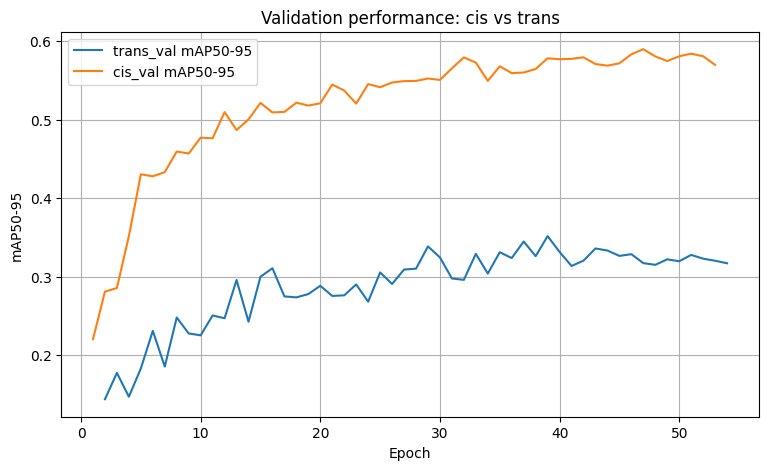

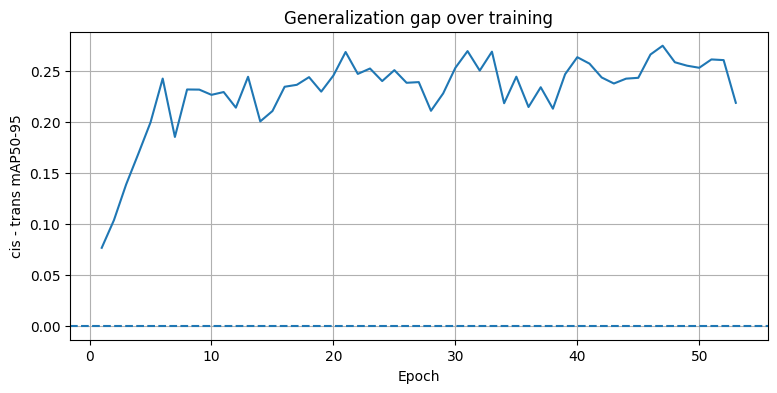

In [11]:
results_csv = exp_dir / "results.csv"
cis_history_csv = exp_dir / "cis_val_history.csv"

if results_csv.exists():
    train_hist = pd.read_csv(results_csv)
    display(train_hist.tail())
else:
    train_hist = None
    print("results.csv not found yet.")

if cis_history_csv.exists():
    cis_hist = pd.read_csv(cis_history_csv)
    display(cis_hist.tail())
else:
    cis_hist = None
    print("cis_val_history.csv not found yet.")

if train_hist is not None:
    plt.figure(figsize=(9, 5))
    x = train_hist["epoch"] + 1 if "epoch" in train_hist.columns else np.arange(1, len(train_hist) + 1)
    if "metrics/mAP50-95(B)" in train_hist.columns:
        plt.plot(x, train_hist["metrics/mAP50-95(B)"], label="trans_val mAP50-95")
    if cis_hist is not None and "cis_mAP50_95" in cis_hist.columns:
        plt.plot(cis_hist["epoch"], cis_hist["cis_mAP50_95"], label="cis_val mAP50-95")
    plt.xlabel("Epoch")
    plt.ylabel("mAP50-95")
    plt.title("Validation performance: cis vs trans")
    plt.legend()
    plt.grid(True)
    plt.show()

if cis_hist is not None and "cis_minus_trans_gap" in cis_hist.columns:
    plt.figure(figsize=(9, 4))
    plt.plot(cis_hist["epoch"], cis_hist["cis_minus_trans_gap"])
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("Epoch")
    plt.ylabel("cis - trans mAP50-95")
    plt.title("Generalization gap over training")
    plt.grid(True)
    plt.show()


## 12. Evaluate the best checkpoint on both test splits


In [12]:
best_model_path = BEST_CKPT if BEST_CKPT.exists() else LAST_CKPT
best_model = YOLO(str(best_model_path))

def evaluate_split(model, data_yaml, split_name, imgsz=IMG_SIZE, batch=BATCH):
    metrics = model.val(
        data=str(data_yaml),
        split="val",
        imgsz=imgsz,
        batch=batch,
        plots=False,
        save_json=False,
        verbose=True,
    )
    metrics_dict = metrics_to_dict(metrics)
    box = getattr(metrics, "box", None)
    row = {
        "split": split_name,
        "mAP50": float(metrics_dict.get("metrics/mAP50(B)", getattr(box, "map50", np.nan))),
        "mAP50_95": float(metrics_dict.get("metrics/mAP50-95(B)", getattr(box, "map", np.nan))),
        "precision": float(metrics_dict.get("metrics/precision(B)", getattr(box, "mp", np.nan))),
        "recall": float(metrics_dict.get("metrics/recall(B)", getattr(box, "mr", np.nan))),
    }
    return row, metrics

eval_rows = []
cis_test_row, cis_test_metrics = evaluate_split(best_model, CIS_TEST_YAML, "cis_test")
eval_rows.append(cis_test_row)

trans_test_row, trans_test_metrics = evaluate_split(best_model, TRANS_TEST_YAML, "trans_test")
eval_rows.append(trans_test_row)

eval_df = pd.DataFrame(eval_rows)
eval_df.to_csv(ARTIFACT_DIR / "test_metrics.csv", index=False)
display(eval_df)


Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,418,992 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.2 ms, read: 14.2±8.3 MB/s, size: 126.7 KB)
val: Scanning /kaggle/working/wildlife_yolo11s_stock_baseline/dataset_yolo/labels/cis_test... 15827 images, 3131 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15827/15827 329.5it/s 48.0s<0.0s
val: New cache created: /kaggle/working/wildlife_yolo11s_stock_baseline/dataset_yolo/labels/cis_test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1979/1979 13.0it/s 2:32<0.2s
                   all      15827      13264      0.752      0.743      0.778      0.515
               opossum       3999       4010      0.979      0.749      0.938      0.505
               raccoon        925        981      0.715      0.914      0.883       0.57
              squirrel        503        510      0.8

,split,mAP50,mAP50_95,precision,recall
0,cis_test,0.778203,0.514975,0.75198,0.742706
1,trans_test,0.486425,0.321051,0.51739,0.500686


## 13. Optional: visualize some predictions


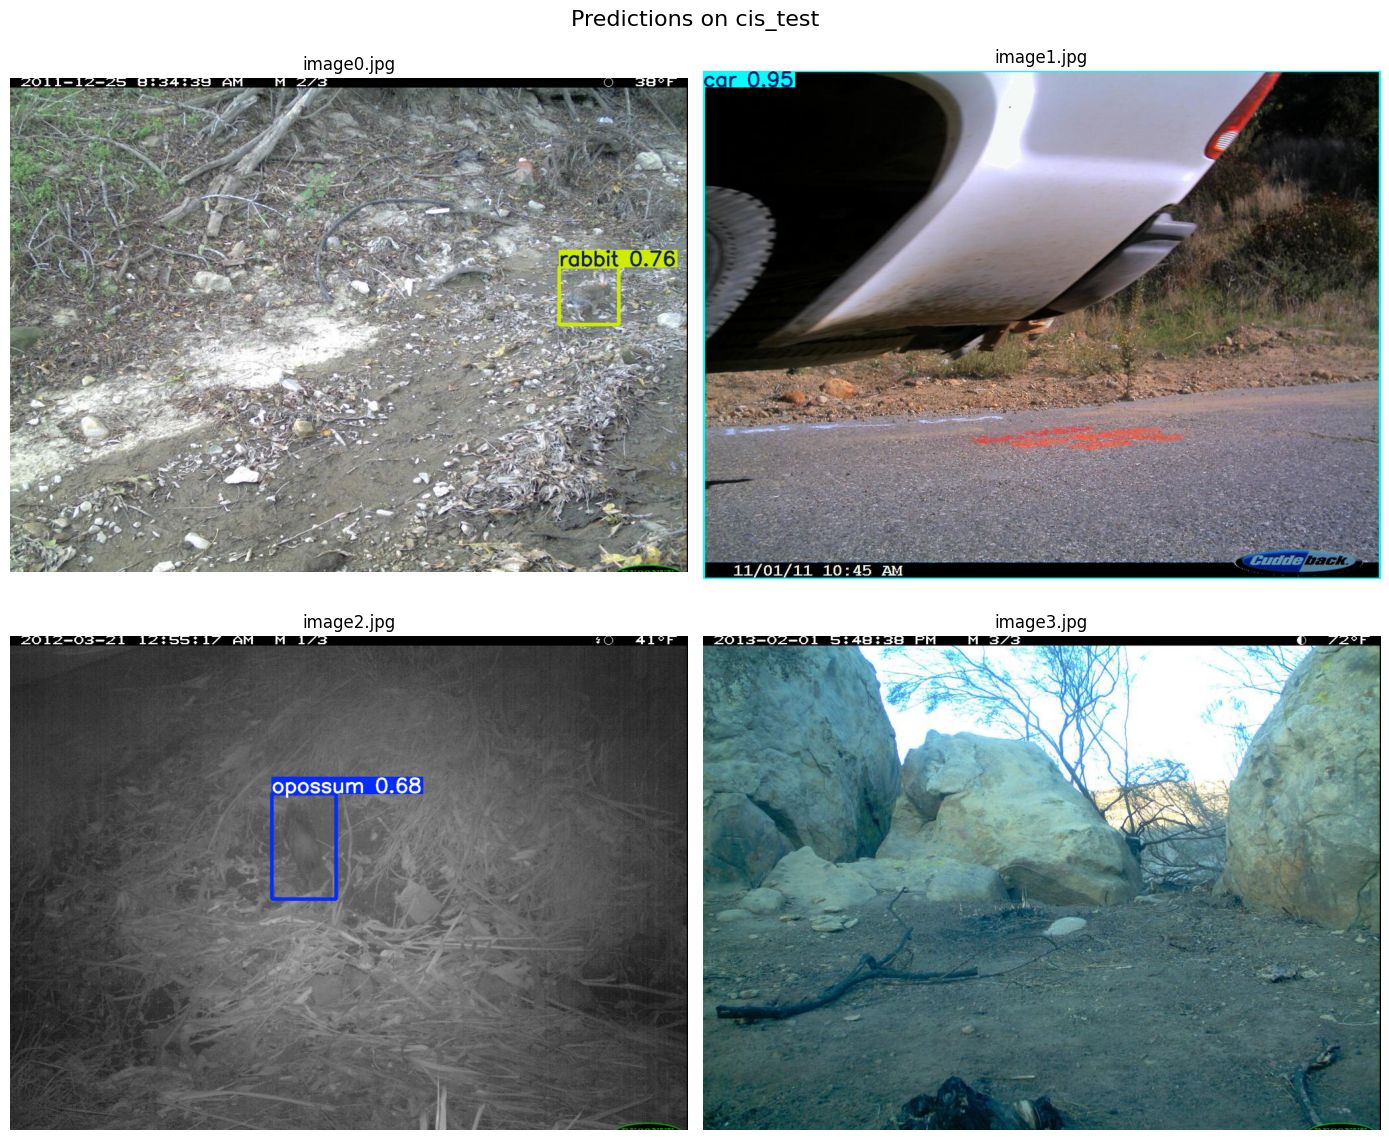

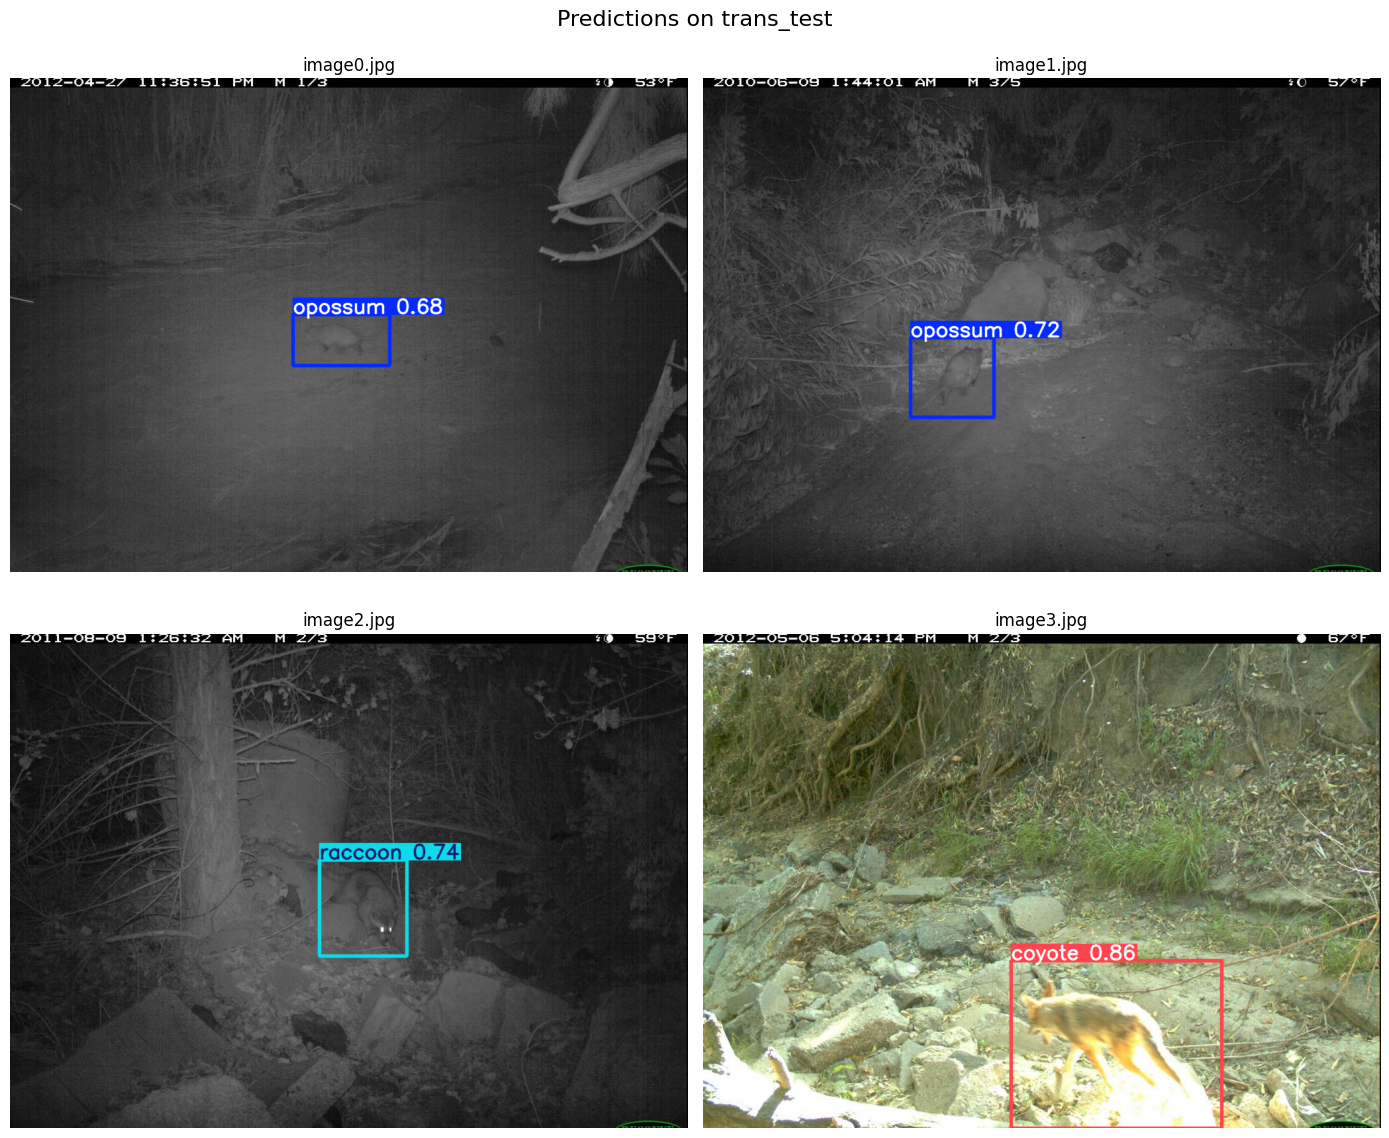

In [13]:
def sample_images(split_name, n=4):
    image_paths = sorted((IMAGES_DIR / split_name).glob("*"))
    if len(image_paths) == 0:
        return []
    n = min(n, len(image_paths))
    random.seed(SEED)
    return random.sample(image_paths, n)

def show_predictions(model, image_paths, title, conf=0.25):
    if len(image_paths) == 0:
        print(f"No images available for {title}")
        return
    results = model.predict(
        source=[str(p) for p in image_paths],
        conf=conf,
        imgsz=IMG_SIZE,
        save=False,
        verbose=False,
    )
    n = len(results)
    cols = 2
    rows = math.ceil(n / cols)
    plt.figure(figsize=(14, 6 * rows))
    for i, r in enumerate(results, start=1):
        plt.subplot(rows, cols, i)
        plt.imshow(cv2.cvtColor(r.plot(), cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(Path(r.path).name)
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

cis_sample = sample_images("cis_test", n=4)
trans_sample = sample_images("trans_test", n=4)

show_predictions(best_model, cis_sample, "Predictions on cis_test")
show_predictions(best_model, trans_sample, "Predictions on trans_test")
